In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from PIL import Image  # For GIF creation
import os
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from itertools import combinations
from tqdm import tqdm

import numpy as np
import pandas as pd
import skimage
import torch

import neuralpredictors

warnings.filterwarnings("ignore")

from nnfabrik.builder import get_data, get_model, get_trainer
from nnfabrik.utility.nn_helpers import set_random_seed

In [ ]:
def ari_baseline(keys1, regularizer):    
    seeds=[10,42,100]
    ari_results = {}         # Stores ARI scores against ground truth
    predictions_dict = {}    

    for k1 in keys1:
        predictions_dict[k1] = {}
        cluster=k1
        for seed in seeds:
            path_ending = f'GMM_without_KL_{cluster}clusters_seed_{seed}{regularizer}'
            predictions_dict[k1][seed] = np.load(f'/predictions/predictions_{path_ending}.npy')

    ari_results = {}  

    for k1 in keys1:
        ari_results[k1] = {}  
        for seed1, seed2 in combinations(seeds, 2):
            try:
                # Check if both seeds exist before computing ARI
                if (seed1 in predictions_dict[k1]and 
                    seed2 in predictions_dict[k1]):
                    ari_score = adjusted_rand_score(
                        predictions_dict[k1][seed1], 
                        predictions_dict[k1][seed2]
                    )
                else:
                    ari_score = np.nan  
            except Exception as e:
                ari_score = np.nan  # Insert None in case of errors

            # Store result
            ari_results[k1][(seed1, seed2)] = ari_score
            #print(f"ARI between seed {seed1} and seed {seed2} for key1 {k1}: {ari_score}")


    ari_values = [list(ari_results[k1].values()) for k1 in keys1]
    ari_means = np.array([np.mean([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])
    ari_stds = np.array([np.std([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])

    return ari_means, ari_stds

In [ ]:
seed = 42
set_random_seed(seed)
predictions_dict = {}
cluster_centers_dict = {}
scale_matrices_dict = {}
heldout_neurons_dict = {}

regularizer = 'adlognorm'
starting_epcoch = 1
multiplier = 1e4
exponent=2.0
clusters=15
alpha=2.1
pretrain_epoch = 10
lr_model=0.008
dim =''
seeds = [10,100,42]
clusters =list(range(2,5)) + list(range(5,55,5))


for cluster in clusters:
    heldout_neurons_dict[cluster] = {}
    predictions_dict[cluster] = {}
    cluster_centers_dict[cluster] = {}
    scale_matrices_dict[cluster] = {}
    for seed in seeds:
        if seed == 42 and cluster <5:
            path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{cluster}_mult_{multiplier}_reg_adaptive_log_norm_pe{pretrain_epoch}_lr_{lr_model}{dim}_seed_{seed}_heldout_neurons'
        else:    
            path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{cluster}_mult_{multiplier}_reg_{regularizer}_pe{pretrain_epoch}_lr_{lr_model}{dim}_seed_{seed}_heldout_neurons'
        weights = torch.load(f'model_checkpoints/sensorium_model_dec_{path_ending}.pth')
        features_list = []
        i=0
        for key, tensor in weights.items():
            if key.endswith('._features') and key.startswith('readout.'):
                features = tensor.detach().squeeze().T  
                features_list.append(features)
                i += 1
        features = np.vstack(features_list)
        heldout_neurons_dict[cluster][seed] = features
        #predictions/predictions_dec_KL_EM_diagcov_alpha_2.1_exp_2.0_cluster_10_mult_10000.0_reg_adlognorm_pe10_lr_0.008_seed_100_heldout_neurons.pt
        predictions_dict[cluster][seed] =torch.load(f'predictions/predictions_dec_{path_ending}.pt').cpu().numpy()
        cluster_centers_dict[cluster][seed] =np.load(f'cluster_centers/cluster_centers_{path_ending}.npy')[-1]
        scale_matrices_dict[cluster][seed] =np.load(f'scale_matrices/scale_{path_ending}.npy')

(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
[4 0 4 ... 1 5 6]
(53169, 128)
[0 0 0 ... 9 5 9]
(53169, 128)
[3 8 3 ... 4 8 4]
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)
(53169, 128)


In [ ]:
ari_results = {}  

for k1 in clusters:
    ari_results[k1] = {}  

    for seed1, seed2 in combinations(seeds, 2):
        try:
            # Check if both seeds exist before computing ARI
            if (seed1 in predictions_dict[k1] and 
                seed2 in predictions_dict[k1]):
                
                # Compute ARI
                ari_score = adjusted_rand_score(
                    predictions_dict[k1][seed1], 
                    predictions_dict[k1][seed2]
                )
            else:
                ari_score = np.nan  
        except Exception as e:
            ari_score = np.nan  # Insert None in case of errors

        # Store result
        ari_results[k1][(seed1, seed2)] = ari_score

ARI between seed 10 and seed 100 for key1 2: 0.4601883293181316
ARI between seed 10 and seed 42 for key1 2: 0.4938428632091222
ARI between seed 100 and seed 42 for key1 2: 0.5340841867054149
ARI between seed 10 and seed 100 for key1 3: 0.4938658786263218
ARI between seed 10 and seed 42 for key1 3: 0.3078985578901276
ARI between seed 100 and seed 42 for key1 3: 0.3294982539526144
ARI between seed 10 and seed 100 for key1 4: 0.48369286103047776
ARI between seed 10 and seed 42 for key1 4: 0.43003243113486306
ARI between seed 100 and seed 42 for key1 4: 0.47808114594090145
ARI between seed 10 and seed 100 for key1 5: 0.41975009336661145
ARI between seed 10 and seed 42 for key1 5: 0.3959580022401913
ARI between seed 100 and seed 42 for key1 5: 0.42614712144103867
ARI between seed 10 and seed 100 for key1 10: 0.32688957450224015
ARI between seed 10 and seed 42 for key1 10: 0.28802076969484774
ARI between seed 100 and seed 42 for key1 10: 0.28344355901571855
ARI between seed 10 and seed 100 f

In [38]:
import numpy as np
from scipy.special import gammaln
from scipy.special import logsumexp

def log_t_pdf(x, mu, var, nu):
    """
    Compute log probability of multivariate Student's t-distribution (diagonal covariance) using NumPy.
    
    Parameters:
    - x: shape (N, D), data points
    - mu: shape (K, D), cluster means
    - var: shape (K, D), diagonal variances per cluster
    - nu: scalar, degrees of freedom

    Returns:
    - log_probs: shape (N, K), log probability of each point under each cluster
    """
    N, D = x.shape
    K = mu.shape[0]


    x = x[:, np.newaxis, :]       # (N, 1, D)
    mu = mu[np.newaxis, :, :]     # (1, K, D)
    var = var[np.newaxis, :, :]   # (1, K, D)

    sq_mahal = np.sum((x - mu)**2 / var, axis=2)  # (N, K)

    log_det = 0.5 * np.sum(np.log(var), axis=2)   # (1, K)

    log_probs = (
        gammaln((nu + D) / 2)
        - gammaln(nu / 2)
        - log_det.squeeze(0)
        - (D / 2) * np.log(nu * np.pi)
        - ((nu + D) / 2) * np.log1p(sq_mahal / nu)
    )  # shape: (N, K)

    return log_probs

In [39]:
def compute_bic(x, mu, var, nu):
    """
    x: (N, D) held-out data
    mu: (K, D)
    var: (K, D)
    pi: (K,) mixture weights (should sum to 1)
    nu: scalar
    """
    N, D = x.shape
    K = mu.shape[0]

    log_probs = log_t_pdf(x, mu, var, nu)  # (N, K)

    log_likelihoods = logsumexp(log_probs, axis=1)  - np.log(K) # (N,)
    print(log_likelihoods.shape)
    logL = log_likelihoods.sum().item()

    # Parameter count
    p = 2 * K * D  + 1

    bic = -2 * logL + p * np.log(N)
    return bic, logL

In [ ]:
bic_results = {}
logl_results = {}
for cluster in clusters:
    bic_results[cluster] = {}
    logl_results[cluster] = {}
    for seed in seeds:
        bic, logL = compute_bic(heldout_neurons_dict[cluster][seed], cluster_centers_dict[cluster][seed] , scale_matrices_dict[cluster][seed],2.1)
        bic_results[cluster][seed] = bic
        logl_results[cluster][seed] = logL

(53169,)
BIC: -23190070.90 | Log-Likelihood: 11597826.49
(53169,)
BIC: -23514113.94 | Log-Likelihood: 11759848.01
(53169,)
BIC: -23521562.14 | Log-Likelihood: 11763572.11
(53169,)
BIC: -23223001.15 | Log-Likelihood: 11615684.41
(53169,)
BIC: -23655868.90 | Log-Likelihood: 11832118.28
(53169,)
BIC: -23639059.27 | Log-Likelihood: 11823713.47
(53169,)
BIC: -23673052.58 | Log-Likelihood: 11842102.92
(53169,)
BIC: -23815686.25 | Log-Likelihood: 11913419.76
(53169,)
BIC: -23760110.26 | Log-Likelihood: 11885631.76
(53169,)
BIC: -23759615.60 | Log-Likelihood: 11886777.23
(53169,)
BIC: -23890575.09 | Log-Likelihood: 11952256.97
(53169,)
BIC: -23754820.92 | Log-Likelihood: 11884379.89
(53169,)
BIC: -24126415.32 | Log-Likelihood: 12077141.08
(53169,)
BIC: -24240141.88 | Log-Likelihood: 12134004.35
(53169,)
BIC: -24074445.74 | Log-Likelihood: 12051156.28
(53169,)
BIC: -23946386.01 | Log-Likelihood: 11994090.41
(53169,)
BIC: -24316330.46 | Log-Likelihood: 12179062.64
(53169,)
BIC: -23922392.71 | Lo

Valid indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
ari_means dtype: float64
ari_stds dtype: float64
ari_means[valid_idx]: [-23408582.32920013 -23505976.4421167  -23749616.3651223
 -23801670.53703682 -24147000.97771491 -24061703.06056644
 -24434782.13076842 -24448009.50675621 -24507425.2580579
 -24439929.81740798 -24451719.56072834 -24539163.8466497
 -24614508.74398424]
ari_stds[valid_idx]: [154540.82784268 200211.39069021  58700.83442178  62895.4759375
  69193.59249512 180315.01223744  71231.7749033   97010.33118311
  97520.31045469 143049.08785858 207100.65682341 175482.50181712
  38529.1510767 ]


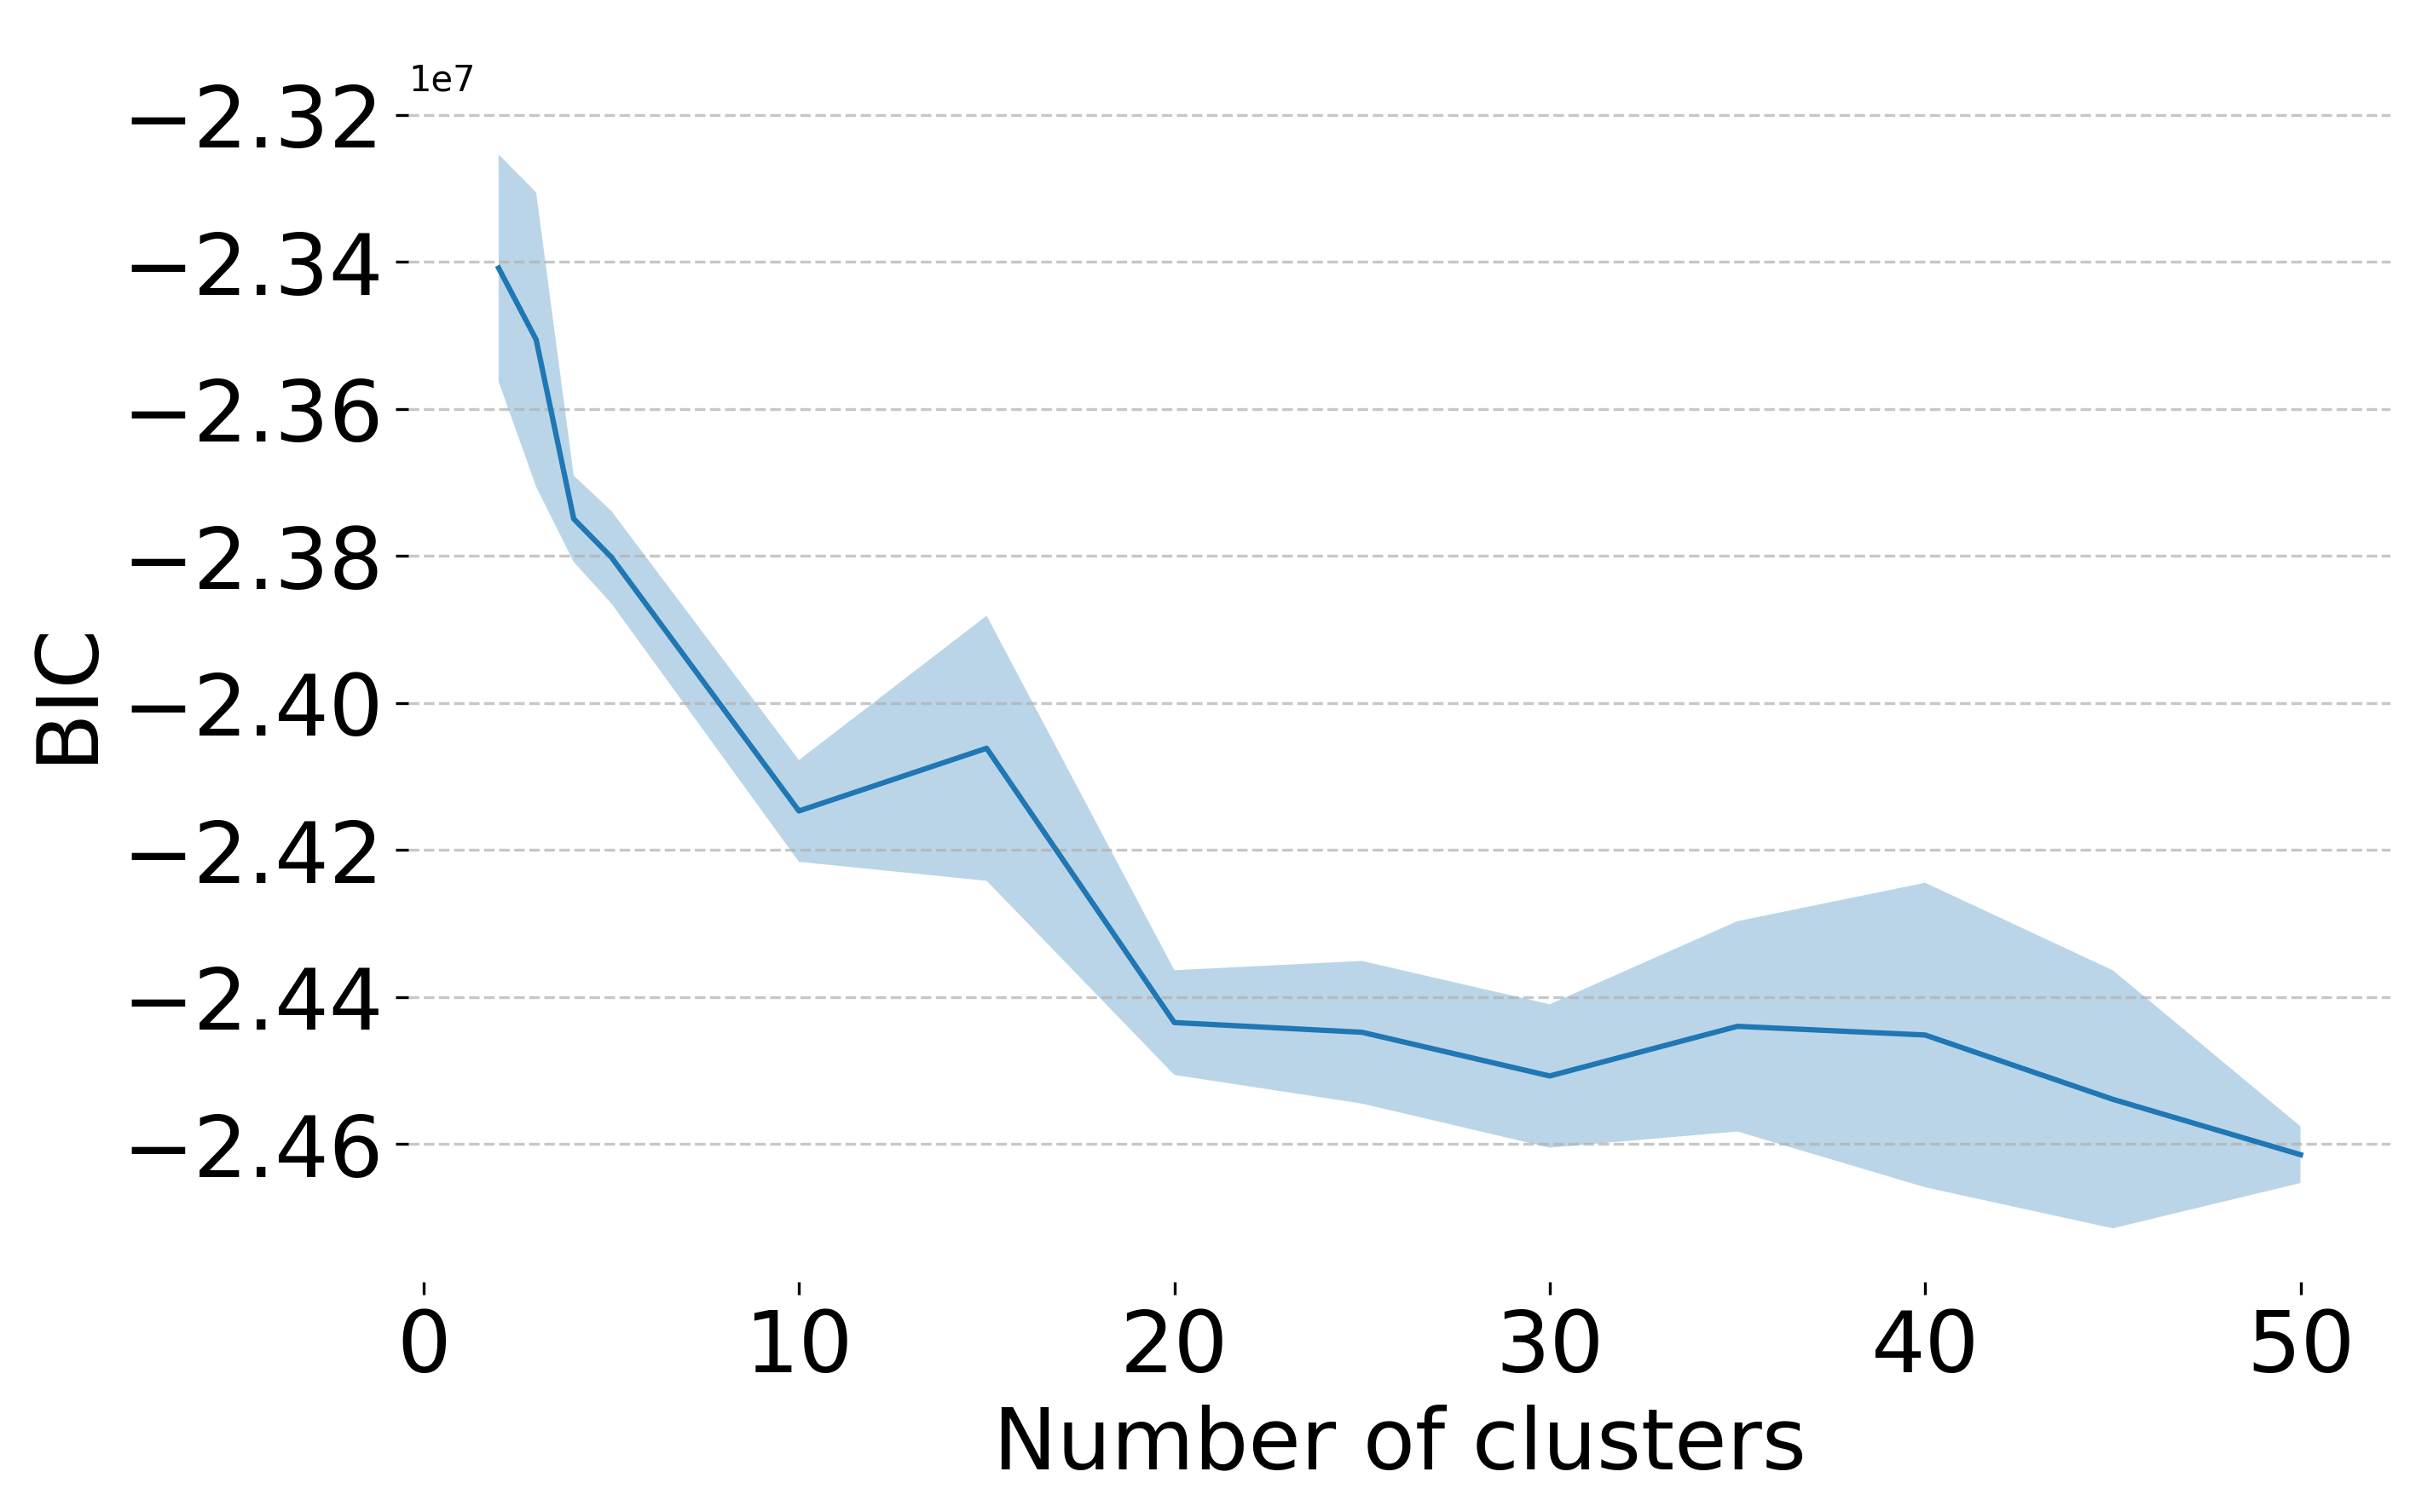

Valid indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
ari_means dtype: float64
ari_stds dtype: float64
ari_means[valid_idx]: [11707082.20029994 11757172.05430046 11880384.8133455  11907804.696845
 12087433.90489522 12051748.93403216 12245252.45684434 12258830.13254941
 12295501.99591145 12268718.26329767 12281577.12266904 12332263.25334089
 12376899.68971935]
ari_stds[valid_idx]: [ 77270.41392134 100105.6953451   29350.41721089  31447.73796875
  34596.79624756  90157.50611872  35615.88745165  48505.16559156
  48760.15522735  71524.54392929 103550.32841171  87741.25090856
  19264.57553835]


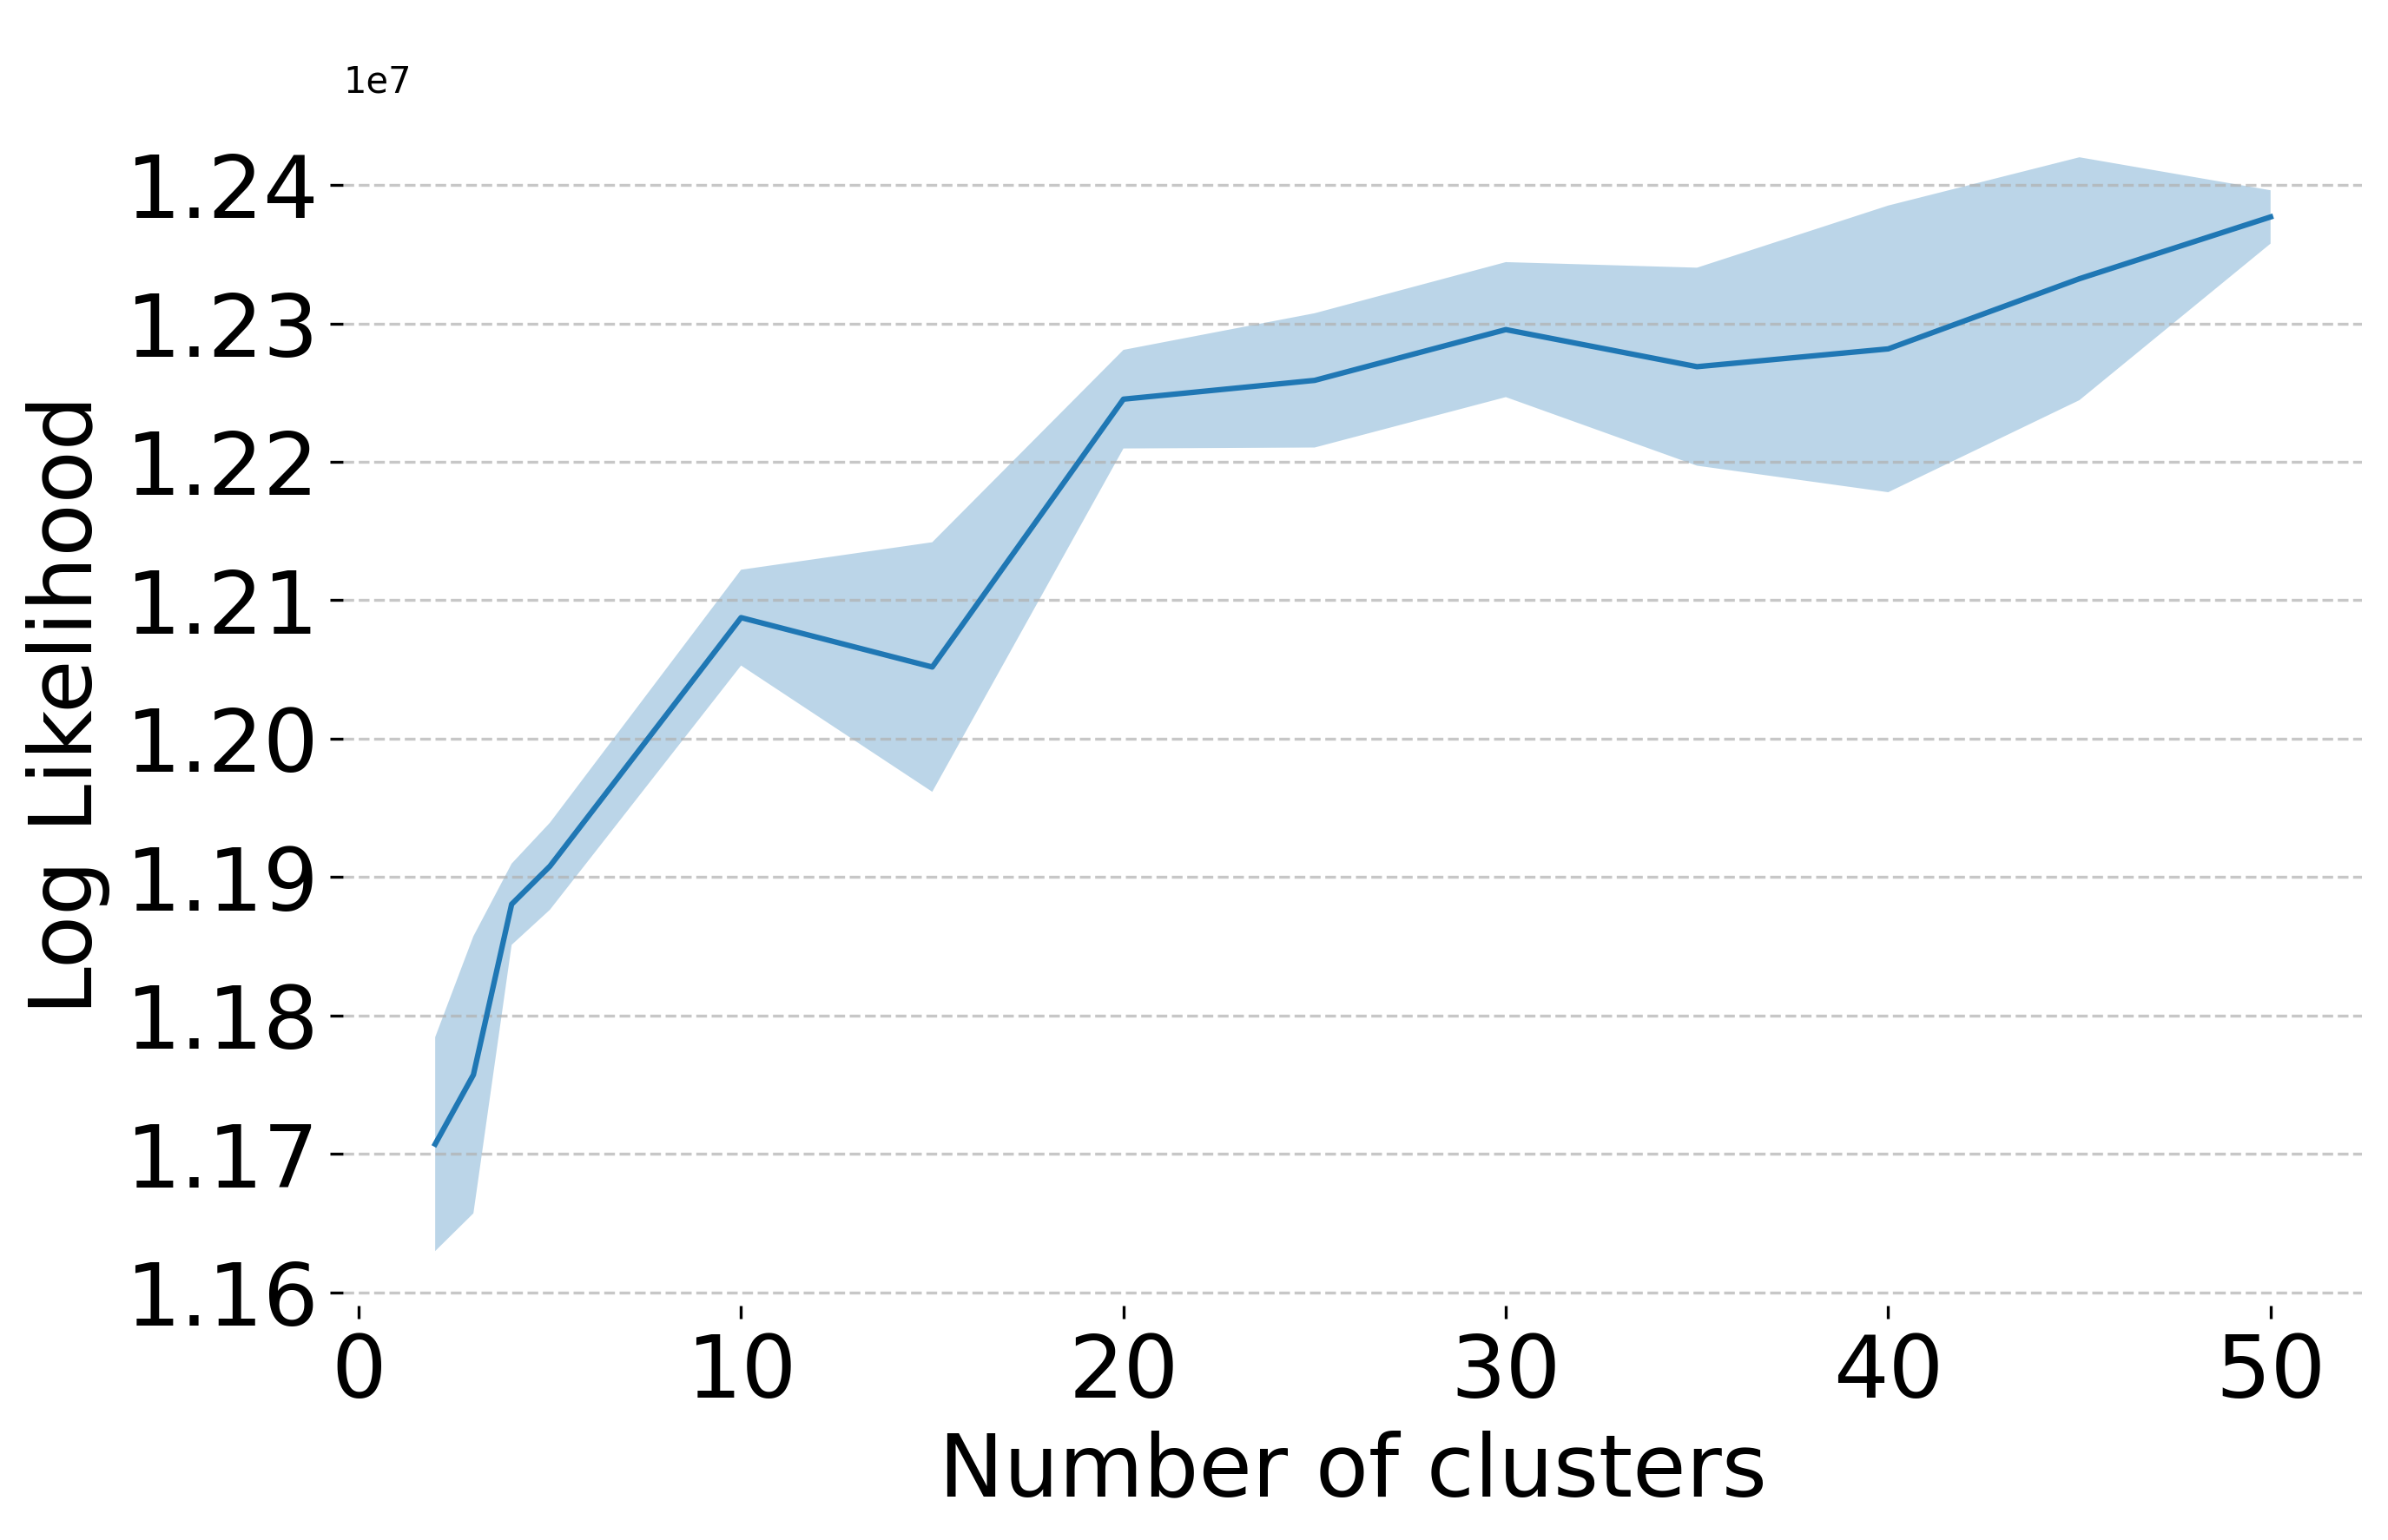

TypeError: plot_ARI() missing 1 required positional argument: 'save_name'

In [ ]:
def plot(keys2,label1,label2, save_name, ari_results):
    fontsize=24

    plt.figure(figsize=(10, 6), dpi=300)

    ari_values = [list(ari_results[k2].values()) for k2 in keys2]
    ari_means = np.array([np.mean([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])
    ari_stds = np.array([np.std([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])


    plt.plot(keys2, ari_means)
    valid_idx = [j for j, v in enumerate(ari_means) if v is not None]

    plt.fill_between(
        np.array(keys2)[valid_idx], 
        ari_means[valid_idx] - ari_stds[valid_idx], 
        ari_means[valid_idx] + ari_stds[valid_idx], 
         alpha=0.3
    )

    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.grid(axis='y', linestyle='--', alpha=0.7) 
    plt.xlabel(f'{label2}', fontsize=fontsize)
    plt.ylabel(f"{label1}", fontsize=fontsize)
    plt.legend(fontsize=fontsize, frameon=False, ncol=1)
    
    handles, labels = plt.gca().get_legend_handles_labels()

    plt.legend(
        handles,
        labels,
        fontsize=fontsize,
        frameon=False,
        ncol=2,
        loc='upper right',    # Legend is anchored at upper right
        bbox_to_anchor=(1, 1.1),  # Move the legend up by increasing the y-coordinate
        columnspacing=0.5,
        handletextpad=0.5,
        borderaxespad=0.5,
        alignment='right'     # Requires matplotlib >= 3.4
    )
    plt.show()
plot(clusters,"BIC", 'Number of clusters','ari_bic', ari_results=bic_results)
plot(clusters,"Log Likelihood", 'Number of clusters','logl', ari_results=logl_results)
plot(clusters,"ARI", 'Number of clusters', ari_results=ari_results)